In [7]:
import sys
import site

USER_SITE = site.getusersitepackages()

if USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

import peft

print("PEFT loaded:", peft.__version__)

PEFT loaded: 0.19.1


In [8]:
from datasets import load_dataset

dataset = load_dataset("nyu-mll/glue", "mrpc")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})


In [9]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize, batched=True)

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("Tokenization done")

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

Tokenization done


In [11]:
from peft import LoraConfig, get_peft_model, TaskType

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

model = get_peft_model(model, lora_config)
model.to("cuda")

model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


In [13]:
import numpy as np
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = (preds == labels).mean()
    f1 = f1_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1
    }

In [17]:
from pathlib import Path

BASE = Path.home() / "MyWork" / "LoRA_Reproduction"

In [18]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=str(BASE / "nlu" / "mrpc" / "output"),

    learning_rate=5e-4,
    num_train_epochs=10,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=10,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    report_to="none"
)

In [20]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [21]:
model.config.use_cache = False
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.677689,0.398111,0.825980,0.872531
2,0.287546,0.398662,0.857843,0.897887
3,0.322225,0.362698,0.848039,0.885185
4,0.298870,0.467611,0.838235,0.890365
5,0.298651,0.420839,0.855392,0.896309
6,0.251764,0.403341,0.852941,0.892086
7,0.176185,0.550808,0.860294,0.899824
8,0.095591,0.481992,0.857843,0.901024
9,0.293406,0.625246,0.855392,0.898451
10,0.076986,0.625210,0.867647,0.904594


TrainOutput(global_step=2300, training_loss=0.2690090374842934, metrics={'train_runtime': 132.5773, 'train_samples_per_second': 276.669, 'train_steps_per_second': 17.348, 'total_flos': 2437716563681280.0, 'train_loss': 0.2690090374842934, 'epoch': 10.0})

In [2]:
from pathlib import Path
import json

BASE = Path.home() / "MyWork" / "LoRA_Reproduction"
LOGS_DIR = BASE / "results" / "logs"
LOGS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
results = {
    "task": "MRPC",
    "model": "roberta-base",
    "method": "LoRA",
    "best_validation_accuracy": 0.867647,
    "best_validation_f1": 0.904594,
    "best_epoch": 10,
    "num_train_epochs": 10,
    "learning_rate": 5e-4,
    "lora_rank": 8,
    "lora_alpha": 16,
    "target_modules": ["query", "value"],
    "trainable_parameters": 887042,
    "trainable_percentage": 0.7066,
}
with open(LOGS_DIR / "mrpc_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("MRPC saved!")

MRPC saved!


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json

RESULTS_DIR = Path.cwd() / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

epochs = list(range(1, 11))

training_loss = [
    0.677689,
    0.287546,
    0.322225,
    0.298870,
    0.298651,
    0.251764,
    0.176185,
    0.095591,
    0.293406,
    0.076986,
]

validation_loss = [
    0.398111,
    0.398662,
    0.362698,
    0.467611,
    0.420839,
    0.403341,
    0.550808,
    0.481992,
    0.625246,
    0.625210,
]

accuracy_scores = [
    0.825980,
    0.857843,
    0.848039,
    0.838235,
    0.855392,
    0.852941,
    0.860294,
    0.857843,
    0.855392,
    0.867647,
]

f1_scores = [
    0.872531,
    0.897887,
    0.885185,
    0.890365,
    0.896309,
    0.892086,
    0.899824,
    0.901024,
    0.898451,
    0.904594,
]

results_df = pd.DataFrame({
    "epoch": epochs,
    "training_loss": training_loss,
    "validation_loss": validation_loss,
    "validation_accuracy": accuracy_scores,
    "validation_f1": f1_scores,
})

display(results_df)

,epoch,training_loss,validation_loss,validation_accuracy,validation_f1
0,1,0.677689,0.398111,0.825980,0.872531
1,2,0.287546,0.398662,0.857843,0.897887
2,3,0.322225,0.362698,0.848039,0.885185
3,4,0.298870,0.467611,0.838235,0.890365
4,5,0.298651,0.420839,0.855392,0.896309
5,6,0.251764,0.403341,0.852941,0.892086
6,7,0.176185,0.550808,0.860294,0.899824
7,8,0.095591,0.481992,0.857843,0.901024
8,9,0.293406,0.625246,0.855392,0.898451
9,10,0.076986,0.625210,0.867647,0.904594


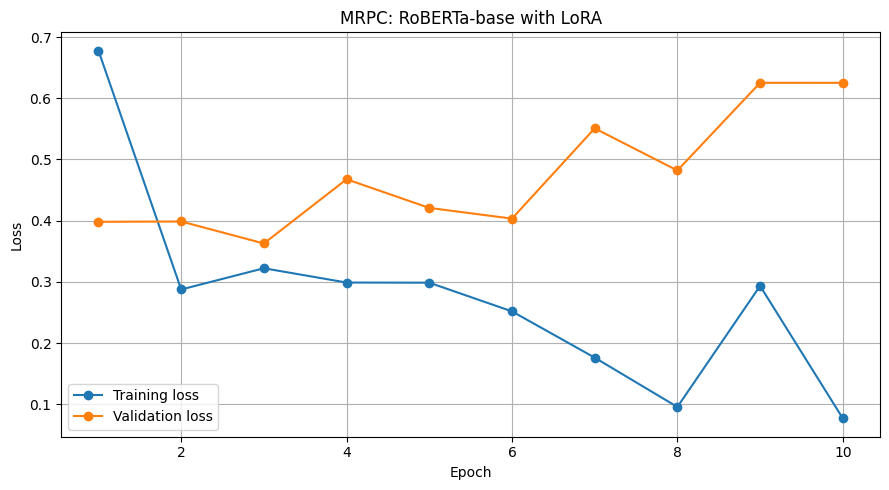

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/mrpc_loss_curve.png


In [4]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training loss",
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MRPC: RoBERTa-base with LoRA")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = RESULTS_DIR / "mrpc_loss_curve.png"

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", loss_plot_path)

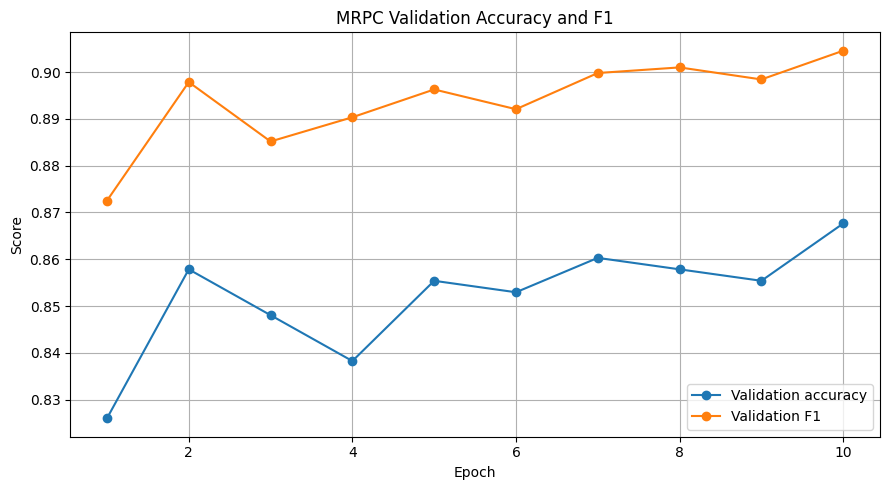

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/mrpc_metrics_curve.png


In [5]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    accuracy_scores,
    marker="o",
    label="Validation accuracy",
)

plt.plot(
    epochs,
    f1_scores,
    marker="o",
    label="Validation F1",
)

best_epoch = epochs[accuracy_scores.index(max(accuracy_scores))]
best_accuracy = max(accuracy_scores)
best_f1 = max(f1_scores)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("MRPC Validation Accuracy and F1")
plt.legend()
plt.grid(True)
plt.tight_layout()

metrics_plot_path = RESULTS_DIR / "mrpc_metrics_curve.png"

plt.savefig(
    metrics_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", metrics_plot_path)

In [6]:
mrpc_results = {
    "task": "MRPC",
    "model": "roberta-base",
    "method": "LoRA",
    "best_validation_accuracy": best_accuracy,
    "best_validation_f1": best_f1,
    "best_epoch_by_accuracy": best_epoch,
    "num_train_epochs": 10,
    "learning_rate": 5e-4,
    "lora_rank": 8,
    "lora_alpha": 16,
    "target_modules": ["query", "value"],
    "trainable_parameters": 887042,
    "trainable_percentage": 0.7066,
}

metrics_path = RESULTS_DIR / "mrpc_results.json"

with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(
        mrpc_results,
        file,
        indent=2,
    )

results_df.to_csv(
    RESULTS_DIR / "mrpc_epoch_history.csv",
    index=False,
)

print("Saved:", metrics_path)

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/mrpc_results.json


## MRPC Results and Analysis

The best validation accuracy was **86.76%**, and the best validation
F1 score was **90.46%**.

Training loss generally decreased throughout training, while validation
loss began increasing during later epochs. This indicates that the
model started to overfit the training data.

Despite the increasing validation loss, validation accuracy and F1
remained relatively stable and reached their highest values at epoch 10.

The experiment trained only 887,042 parameters, approximately 0.71%
of the full RoBERTa-base model.